In [2]:
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [4]:
df = pd.read_csv('/content/raw.csv')

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


In [9]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [10]:
df['race_ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [11]:
df['parental_level_of_education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [12]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [13]:
df['test_preparation_course'].unique()

array(['none', 'completed'], dtype=object)

In [14]:
# Dependent and Independent features
X = df.drop(['math_score'], axis = 1)
y = df['math_score']

In [16]:
categorical_cols = ['gender',	'race_ethnicity',	'parental_level_of_education',	'lunch',	'test_preparation_course']
numerical_cols = ['reading_score', 'writing_score']

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [18]:
# numerical pipeline
num_pipeline = Pipeline(
        steps = [
            ('imputer', SimpleImputer(strategy = 'median')),
            ('scaler', StandardScaler())])

In [19]:
# categorical pipeline
cat_pipeline = Pipeline(
        steps = [('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('onehotencoder', OneHotEncoder())])

In [21]:
preprocessor = ColumnTransformer([
    ('num_pipeline', num_pipeline, numerical_cols),
    ('cat_pipeline', cat_pipeline, categorical_cols)])

In [22]:
X = preprocessor.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "SVR": SVR()

}

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [69]:
def evaluate_models(X_train, X_test, y_train, y_test, models):
    report = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        report[name] = {
            "R2": r2,
            "RMSE": rmse,
            "MAE": mae
        }

    return report

In [70]:
evaluate_models(X_train, X_test, y_train, y_test, models)

{'Linear Regression': {'R2': 0.8856483575121139,
  'RMSE': np.float64(5.437549102607514),
  'MAE': 4.162865058779922},
 'Lasso': {'R2': 0.8282675466888072,
  'RMSE': np.float64(6.663588582170158),
  'MAE': 5.145619663230457},
 'Ridge': {'R2': 0.8859507483061704,
  'RMSE': np.float64(5.43035483230377),
  'MAE': 4.157447041792991},
 'K-Neighbors Regressor': {'R2': 0.8083357287941408,
  'RMSE': np.float64(7.039674347963344),
  'MAE': 5.4368159203980095},
 'Decision Tree': {'R2': 0.7278090886342197,
  'RMSE': np.float64(8.389166195322174),
  'MAE': 6.656716417910448},
 'Random Forest Regressor': {'R2': 0.8378770292759126,
  'RMSE': np.float64(6.474470625876532),
  'MAE': 5.021270433546554},
 'XGBRegressor': {'R2': 0.8117634654045105,
  'RMSE': np.float64(6.976440838717336),
  'MAE': 5.331750869750977},
 'CatBoosting Regressor': {'R2': 0.8535093051401479,
  'RMSE': np.float64(6.154418257737495),
  'MAE': 4.658982145461262},
 'AdaBoost Regressor': {'R2': 0.8267779112531007,
  'RMSE': np.floa

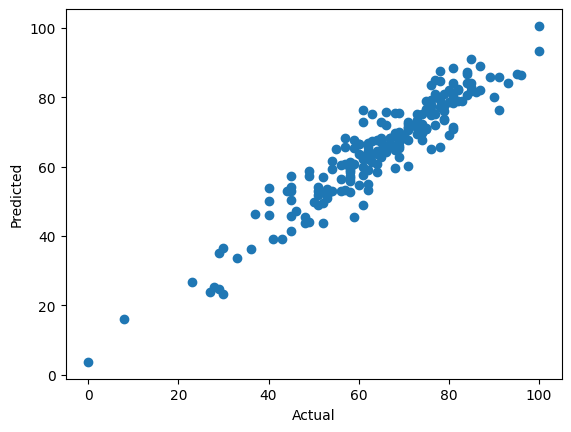

In [71]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

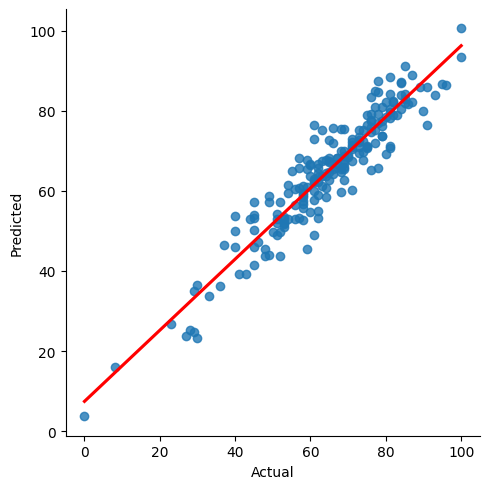

In [72]:
df_plot = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

sns.lmplot(
    x='Actual',
    y='Predicted',
    data=df_plot,
    ci=None,
    line_kws={'color': 'red'}
)

In [73]:
df_plot

,Actual,Predicted
521,91,76.442791
941,78,84.574940
741,37,46.439409
980,8,16.099804
411,84,87.278823
...,...,...
332,62,62.293836
208,74,67.587426
992,55,65.081572
78,61,62.257564


In [66]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.442791,14.557209
941,78,84.574940,-6.574940
741,37,46.439409,-9.439409
980,8,16.099804,-8.099804
411,84,87.278823,-3.278823
...,...,...,...
332,62,62.293836,-0.293836
208,74,67.587426,6.412574
992,55,65.081572,-10.081572
78,61,62.257564,-1.257564


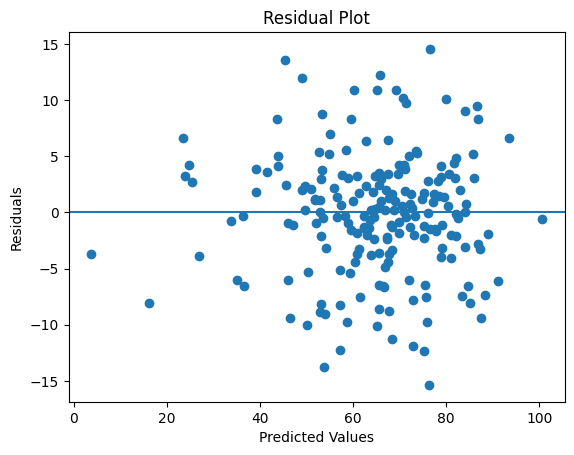

In [67]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)
plt.show()

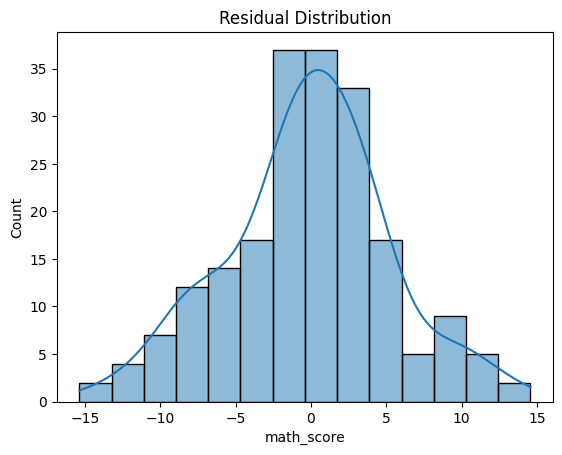

In [68]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()